# Welcome to sedcreator version 2!

`sedcreator` <font size="3"> version 2 presents new and updated tools for analyzing protostars in crowded star-forming environments, where flux contamination from close neighbors typically complicates the process.

<font size="3">Before we start, make sure you have `sedcreator` version 2 installed. It can be installed by typing:</font>

```pip install sedcreator==2.0.0```


<font size="3"> In some distributions you may need to type `pip3` instead, so it would be:</font>
    

```pip3 install sedcreator==2.0.0```

-------

<font size="3">`sedcreator` is composed of two main classes, `SedFluxer` and `SedFitter`, to construct and fit **Spectral Energy Distributions (SEDs)**. 

*The main purpose of `SedFluxer` is to measure fluxes from astronomical images. It includes functions to retrieve the flux (using aperture photometry) and useful information from the data and to plot the used image together with the chosen central coordinates and apertures (see below for more details).*

*The main purpose of `SedFitter` is to fit these measured fluxes. It uses the Zhang & Tan (2018) model grid. It includes a number of functions to retrieve the best models, plot SEDs, and more.*

If you make use of sedcreator in your work or as a dependency of another package, please include the following citation/acknowledgment:</font> https://sedcreator.readthedocs.io/en/latest/citation.html

#### The full documentation can be accessed in this link: https://sedcreator.readthedocs.io/en/latest/index.html
-------
-------

# Example for star-forming region G18.67

In this notebook, we will walk you through an example using `SedFluxer` and `SedFitter` to build and fit the SEDs for all of the protostars in the star-forming region G18.67+00.03 (which we will call G18.67). This region contains five protostars.

*For an example analyzing a single isolated protostar, please see [SedFluxer_example-v0.9.8.ipynb](https://github.com/fedriani/sedcreator/blob/main/examples/SedFluxer_example-v0.9.8.ipynb) and [SedFitter_example-v0.9.8.ipynb](https://github.com/fedriani/sedcreator/blob/main/examples/SedFitter_example-v0.9.8.ipynb)*

-------

First, make sure you are running the correct version:

In [1]:
import sedcreator
sedcreator.__version__

We start by importing the required packages:

In [2]:
from sedcreator import SedFluxer, SedFitter, ModelPlotter
from astropy.io import fits as pyfits
from astropy.coordinates import SkyCoord

import matplotlib.pylab as plt
import numpy as np

# First basic example

We will use infrared images from the high-mass star-forming region G18.67. In the [GitHub repository](https://github.com/fedriani/sedcreator), the data for this notebook is stored in the **G18.67_data** directory within the [examples](https://github.com/fedriani/sedcreator/tree/main/examples) folder. 


In the next few cells, we will demonstrate how to use the basic `SedFluxer` functions for G18.67 source 1 (the primary source in the region) for one image, Herschel 70 µm. 
The workflow is as follows:

1. Open a fits file with valid data and header
2. Initialize the `SedFluxer` class
3. Define the central coordinates, aperture radius, and inner and outer radii for the annulus (if background subtraction is needed).
4. With the above defined, the function get_flux() -or get_raw_flux()- can be used to retrieved the flux by performing aperture photometry. In particular get_flux() will make automatic unit transformations in order to output the results in Jy, provided that the header has units supported by SedFluxer. If you prefer to make your own unit transformations, you can use get_raw_flux() (the usage and syntax is the same)

In [ ]:
#1)
#Here we open the FITS file with astropy.io fits
G18pt67_H70_fits = pyfits.open('G18.67_data/G18.67_Herschel_70.fits')

#2)
#Initialize the SedFluxer
#Make sure you select the appropiate data extension for the image.
#In the case of Herschel is [1], i.e. the second, but usually is the first, i.e., [0]
G18pt67_H70_fluxer = SedFluxer(G18pt67_H70_fits[1])

#3)
#Define the central coordinates of each source
G18pt67_source1_coords = SkyCoord(ra='18h24m53.82716201s', dec='-12d39m18.67892535s', frame='fk5')

#For this initial example, an arbitrary value is given (basically chosen by eye);
#See below for more details on how to chose the aperture radius
G18pt67_source1_aper_rad = 15 #arcsec

#4)
#get_flux() accepts five inputs as shown below.
#For this example, we consider the annulus with the width equal to the aperture radius.
#If mask is not None, it will mask those pixels so they will not be considered in the
#calculation of the flux. Default is None.
G18pt67_source1_H70_gt = G18pt67_H70_fluxer.get_flux(central_coords=G18pt67_source1_coords,
                                               aper_rad=G18pt67_source1_aper_rad,
                                               inner_annu=1.0*G18pt67_source1_aper_rad,
                                               outer_annu=2.0*G18pt67_source1_aper_rad,
                                               mask=None)


Once get_flux has been run, we can retrieve the background-subtracted flux and the NON subtracted flux, respectively. We can also print useful information about the data and plot the resulting image with the selected inputs.

In [4]:
G18pt67_source1_flux_bkg, G18pt67_source1_H70_flux, G18pt67_source1_H70_flu, G18pt67_source1_H70_bkg = G18pt67_source1_H70_gt.value #Jy
print('Background-subtracted flux:', G18pt67_source1_flux_bkg, '\nNon- background-subtracted flux:', G18pt67_source1_H70_flux, '\nFluctuation error:', G18pt67_source1_H70_flu, '\nBackground:', G18pt67_source1_H70_bkg)

Background-subtracted flux: 165.58767025425897 
Non- background-subtracted flux: 177.41549515519807 
Fluctuation error: 23.323738099465515 
Background: 11.827824900939108


In [5]:
G18pt67_source1_H70_gt.info

The aperture used is 15.0 arcsec
pixel scale is 3.2 arcsec/pixel
~ 4.687 pixels are used for the aperture radius
units in the image are: Jy/pixel
Observing date:
No information found in this header
Wavelength:
No information found in this header
############################
Flux bkg sub 165.58767025425897 Jy
Flux         177.41549515519807 Jy
Fluc error   23.323738099465515 Jy
Background   11.827824900939106 Jy
############################


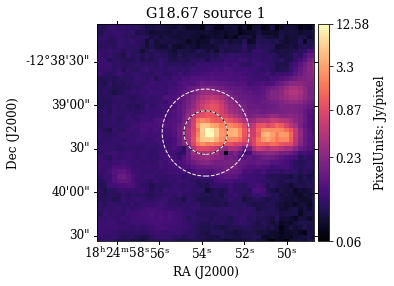

In [26]:

G18pt67_source1_H70_gt.plot(cmap='magma',percent=100.0,stretch='log',
                     colorbar=True,aperture_color='black',annulus_color='white',
                     plot_mask=False,title='G18.67 source 1',figname=None)

# Example for multiple sources

In the above cells, we computed the Herschel 70 µm flux for one source in G18.67. However, in the image above, we can see that the region G18.67 contains more than one source. In order to analyze each of these sources, we first need to define a central coordinate and aperture radius for each one.

In [7]:
G18pt67_coords = [SkyCoord(ra='18h24m53.82716201s', dec='-12d39m18.67892535s', frame='fk5'),
                    SkyCoord(ra='18h24m50.2399519s', dec='-12d39m19.96114827s', frame='fk5'),
                    SkyCoord(ra='18h24m52.6506919s', dec='-12d39m18.34134157s', frame='fk5'),
                    SkyCoord(ra='18h24m51.10987874s', dec='-12d39m20.60318255s', frame='fk5'),               
                    SkyCoord(ra='18h24m53.59354511s', dec='-12d39m01.00480686s', frame='fk5')]


## Getting the optimal apertures

sedcreator version 1 introduced an “optimal aperture algorithm” to determine the aperture size of an isolated extended source in an unbiased and reproducible way. 

In sedcreator version 2, we introduce an updated algorithm designed to work in crowded regions. If only one source coordinate is provided, the algorithm will simply output the corresponding "optimal" aperture radius that maximizes the flux while minimizing background noise (see `sedcreator` documentation for more details). 

If a list of coordinates is provided, the new algorithm determines each radius while considering all neighboring sources in an iterative process until a solution is converged upon for each one. In this scenario, the algorithm outputs a **list of apertures** corresponding to the provided coordinates and a **list of masks** that tell us which pixels have been assigned to each source to avoid double counting any flux.


This algorithm is encapsulated in the function `get_optimal_aperture()` and its usage is as follows (using the fluxer object and coordinates from above). Here we will use the Herschel 70 µm image (which is near the peak of the SED) to generate apertures that we will apply at all wavelengths.

iteration number: 0
iteration number: 1
iteration number: 2
iteration number: 3


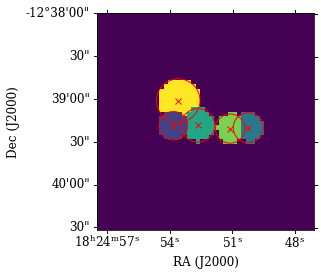

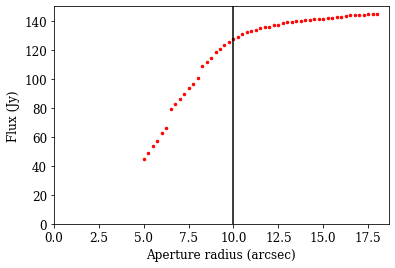

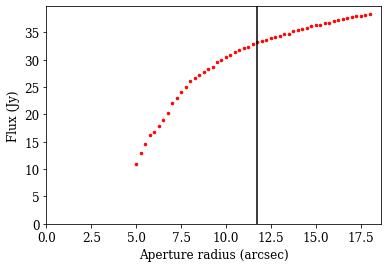

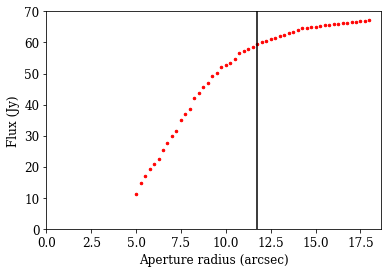

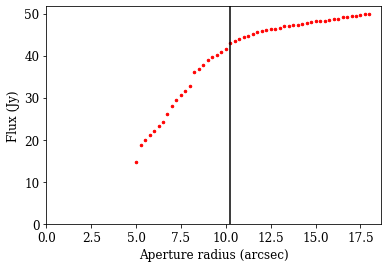

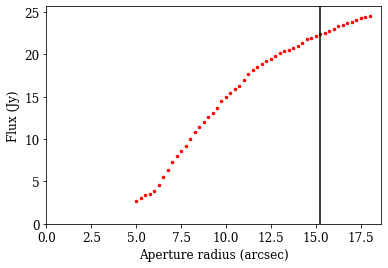

The optimal apertures are [10.0, 10.5, 11.75, 10.25, 15.25] arcsec


In [27]:
G18pt67_opt_aper, G18p67_masks_H70 = G18pt67_H70_fluxer.get_optimal_aperture(central_coords=G18pt67_coords,
                                                             ap_inner=5.0,ap_outer=60.0,step_size=0.25,
                                                             aper_increase=1.3,threshold=1.1,profile_plot=True, plot_map=True)

print('The optimal apertures are', G18pt67_opt_aper,'arcsec')

Here, the first plot shows a color-coded map indicating which source each pixel is assigned to. The other five plots show the profiles of the background-subtracted flux v.s. aperture radius for a range of radii, where the vertical black line indicates the selected "optimal aperture" radius. 

We can now plot the selected apertures. Note that even though they overlap, the outputted masks will tell us which pixels have been assigned to each aperture so that each one is only counted once when calculating fluxes.

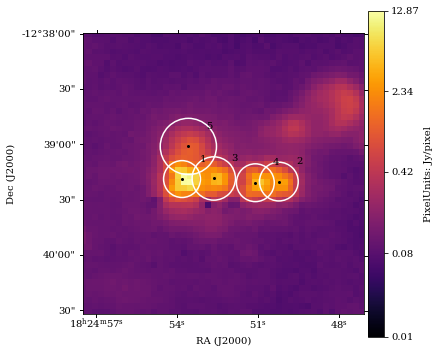

In [9]:
G18pt67_H70_fluxer.plot_multiple_aps(G18pt67_coords, G18pt67_opt_aper, show=False)

## Loading the Images

We will now load the rest of the images we want to use in our analysis. For each source, we will measure its flux in each of these images to build its SED. In this example, we will use images from Spitzer, SOFIA, and Herschel. 

In [10]:
#Here we open the FITS files with astropy.io fits

#Spitzer images
G18p67_S58_fits = pyfits.open('G18.67_data/G18.67_Spitzer_58.fits')
G18p67_S80_fits = pyfits.open('G18.67_data/G18.67_Spitzer_80.fits')

#SOFIA images
G18p67_SO7_fits = pyfits.open('G18.67_data/G18.67_SOFIA_7.7.fits')
G18p67_SO19_fits = pyfits.open('G18.67_data/G18.67_SOFIA_19.7.fits')
G18p67_SO31_fits = pyfits.open('G18.67_data/G18.67_SOFIA_31.5.fits')
G18p67_SO37_fits = pyfits.open('G18.67_data/G18.67_SOFIA_37.1.fits')

#Herschel images
G18p67_H70_fits = pyfits.open('G18.67_data/G18.67_Herschel_70.fits')
G18p67_H160_fits = pyfits.open('G18.67_data/G18.67_Herschel_160.fits')
G18p67_H250_fits = pyfits.open('G18.67_data/G18.67_Herschel_250.fits')
G18p67_H350_fits = pyfits.open('G18.67_data/G18.67_Herschel_350.fits')
G18p67_H500_fits = pyfits.open('G18.67_data/G18.67_Herschel_500.fits')

In [11]:
#Define a list of your images
G18p67_images = [G18p67_S58_fits[0], G18p67_S80_fits[0], #Spitzer images
                 G18p67_SO7_fits[0], G18p67_SO19_fits[0], G18p67_SO31_fits[0], G18p67_SO37_fits[0], #SOFIA images
                 G18p67_H70_fits[1], G18p67_H160_fits[1], G18p67_H250_fits[1], G18p67_H350_fits[1],  G18p67_H500_fits[1]] #Herschel images

#Then, make an array of the corresponding wavelengths (in microns) in the same order
G18p67_wavelengths = np.array([ 5.8, 8.0, #Spitzer wavelengths
                                7.7, 19.7, 31.5, 37.1, #SOFIA wavelengths
                                70.0, 160., 250., 350., 500.]) #Herschel wavelengths

## Regridding masks

We are going to use the same central coordinates and optimal apertures calculated above for all images. However, since the generated masks correspond to the Herschel 70 µm image, we first need to re-grid these masks to fit the pixel scale of each other image.

To do this, we will use the regrid_masks() function for each source and provide it with the list of images we want masks for, in addition to the initial mask and image we used to generate it.

Note that this might take ~1-2 minutes in this example.

In [12]:
G18pt67_masks_regridded = []

for mask in G18p67_masks_H70:
    masks_regridded = G18pt67_H70_fluxer.regrid_masks(images=G18p67_images, master_img=G18p67_H70_fits[1], master_mask=mask)
    G18pt67_masks_regridded.append(masks_regridded)

a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating

## Computing fluxes and building SEDs

We can now construct the SEDs. We will use SedFluxer's get_flux() method to compute the flux for each source at each wavelength. The masks indicate which pixels have been assigned to each source in a given image so that we don't double count any flux.

We also estimate an error for each measurement. In this example, we use the background as the error estimate when λ > 100 µm. At shorter wavelengths, the images are negligibly affected by cold clump contamination, so we instead use the "fluctuation error method" described in the full documentation. For either method, a systematic error of 10% of the background-subtracted flux is added in quadrature.

In [13]:
G18pt67_ALL_flux_bkg = np.zeros((len(G18pt67_coords), len(G18p67_images)))
G18pt67_ALL_err = np.zeros((len(G18pt67_coords), len(G18p67_images)))

#Iterate through the sources
for i in range(len(G18pt67_coords)):
    #Obtain the central coordinates of the current source
    source_coords = G18pt67_coords[i]
    #Optimal aperture radius estimated for the current source
    radius = G18pt67_opt_aper[i]
    #List of masks corresponding to the current source at each wavelength
    masks = G18pt67_masks_regridded[i]
    #Calcuate the flux and errors at each wavelength
    for j, image in enumerate(G18p67_images):
        fluxer_container = SedFluxer(image).get_flux(central_coords=source_coords,
                                            aper_rad=radius,
                                            inner_annu=1.0*radius,
                                            outer_annu=2.0*radius, mask=masks[j])
        
        flux_bkg, flux, err_flux, bkg = fluxer_container.value
        
        #Systematic error (10% of the background-subtracted flux)
        syst_err = flux_bkg*0.1
        #Fluctuation error
        error_fluc = np.sqrt(np.array(err_flux)**2+np.array(syst_err)**2)
        #Background-derived error
        error_bkg = np.sqrt(np.array(bkg)**2+np.array(syst_err)**2) 
       
        #Set the error value corresponding to source i and wavelength j
        G18pt67_ALL_err[i, j] = error_fluc if G18p67_wavelengths[j]<100.0 else error_bkg
        #Set the background-subtracted flux value corresponding to source i and wavelength j
        G18pt67_ALL_flux_bkg[i, j] = flux_bkg


a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]


a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected. [astropy.wcs.wcs]


Now that we have measured the fluxes for our images, let's put them all together and plot them

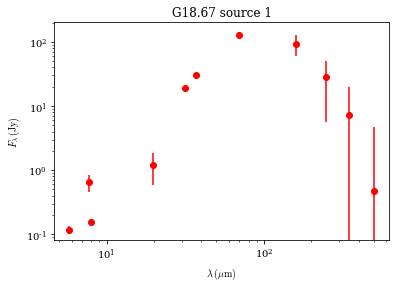

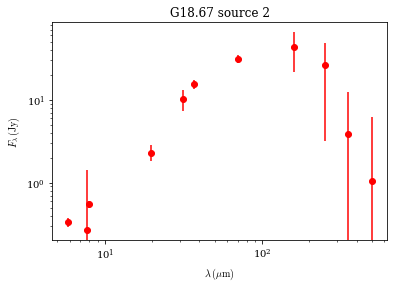

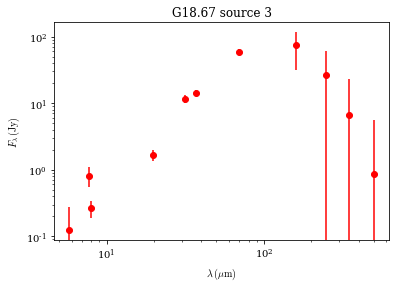

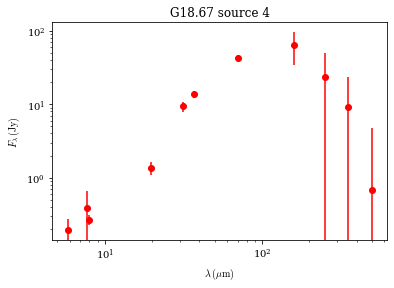

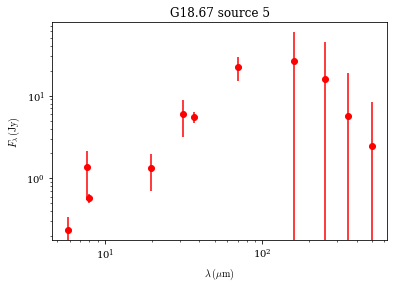

In [14]:
for i in range(len(G18pt67_coords)):
    plt.figure(figsize=(6,4))
    plt.errorbar(G18p67_wavelengths, G18pt67_ALL_flux_bkg[i], yerr=G18pt67_ALL_err[i], fmt='ro')
    #errors for some wavelengths are fairly small so they are within the marker
    plt.title('G18.67 source ' + str(i+1))
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$\lambda\,(\mathrm{\mu m})$')
    plt.ylabel(r'$F_\lambda\,(\mathrm{Jy})$')
    plt.show()

## Fitting the SEDs and plotting the results

Now we will use the second main `sedcreator` class, `SedFitter`, to fit the SEDs. `SedFitter` uses the Zhang & Tan (2018) model grid. It includes a number of functions to retrieve the best models, plot SEDs, and more. The workflow is as follows:

1. Define the 5 inputs arrays that the SedFitter class needs. These are:
- Wavelength array
- Flux array
- Error Flux array
- Upper limits array
- Filter Names array

2. Define distance (dist) to the region and maximum visual extinction (AV_max) value allowed for the fits

3. Initialize the `SedFitter` class for each source

4. Use the function sed_fit() to perform the fitting for each source

We will use the flux array amd error flux array that we obtained using `SedFluxer`. We also need to define what fluxes are upper limits and the names of the filters so the model can be convolved by the filter response of the specific instrument used.

In the Zhang and Tan (ZT) model grid, all fluxes below 8µm are considered upper limits as these may be affected by Polycyclic Aromatic Hydrocarbon (PAH) emission and thermal emission from very small grains that are transiently heated by single photons. Neither of these effects are included in the ZT radiative transfer models. Therefore, we treat the data at these wavelengths as upper limit constraints on the models.

You may not be familiar with the filter names of the model, but you can run the following to find it out (see examples to learn how to add your own filters)

In [15]:
SedFitter().print_default_filters

filter wavelength   instrument  
------ ---------- --------------
    2J        1.2          2MASS
    2H        1.6          2MASS
    2K        2.2          2MASS
    I1        3.6   Spitzer_IRAC
    I2        4.5   Spitzer_IRAC
    I3        5.6   Spitzer_IRAC
    I4        8.0   Spitzer_IRAC
    M1       24.0   Spitzer_MIPS
    M2       70.0   Spitzer_MIPS
    M3      160.0   Spitzer_MIPS
    F1        5.4  SOFIA_FORCAST
    F2        6.4  SOFIA_FORCAST
    F3        6.6  SOFIA_FORCAST
    F4        7.7  SOFIA_FORCAST
    F5        8.6  SOFIA_FORCAST
    F6       11.1  SOFIA_FORCAST
    F7       11.3  SOFIA_FORCAST
    F8       19.2  SOFIA_FORCAST
    F9       24.2  SOFIA_FORCAST
    L1       31.5  SOFIA_FORCAST
    L2       33.6  SOFIA_FORCAST
    L3       34.8  SOFIA_FORCAST
    L4       37.1  SOFIA_FORCAST
    P1       70.0  Herschel_PACS
    P2      100.0  Herschel_PACS
    P3      160.0  Herschel_PACS
    P4      250.0 Herschel_SPIRE
    P5      350.0 Herschel_SPIRE
    P6    

In [35]:
# Step 1)

#Define the image wavelengths (in microns)
G18p67_wavelengths = np.array([5.8, 8.0, #Spitzer wavelengths
                                7.7, 19.7, 31.5, 37.1, #SOFIA wavelengths
                                70.0, 160., 250., 350., 500.]) #Herschel wavelengths

#Copy the background-subtracted flux array obtained using SEDFluxer
G18p67_flux_bkg = G18pt67_ALL_flux_bkg.copy()

#Copy the error array obtained using SEDFluxer
G18pt67_err = G18pt67_ALL_err.copy()

#Create an array where a "1" indicates that the flux at the corresponding wavelength will be considered an upper limit
G18p67_upper_lims = np.array([1, 1,  #Spitzer fluxes are upper limits
                               1, 0, 0, 0, 
                               0, 0, 0, 0, 0])

#Define the filter names (in the same order)
G18p67_filters = np.array(['I3', 'I4', #Spitzer filter names
                           'F4', 'F8', 'L1', 'L4', #SOFIA filter names
                            'P1', 'P3', 'P4', 'P5', 'P6']) #Herschel filter names


In [36]:
# Step 2)

G18p67_dist = 10800 #pc
AV_min = 0 #mag
AV_max = 1000 #mag

In [37]:
# Step 3)

G18p67_fitters = []

for i in range(len(G18pt67_coords)):
    
    source_name = 'G18.67 source ' + str(i+1)
    
    fitter = (SedFitter(extc_law='kmh', 
                    lambda_array=G18p67_wavelengths, 
                    flux_array=G18pt67_ALL_flux_bkg[i], 
                    err_flux_array=G18pt67_ALL_err[i],
                    upper_limit_array=G18p67_upper_lims,
                    filter_array= G18p67_filters))
    
    G18p67_fitters.append(fitter)

In [38]:
# Step 4)

G18p67_sed_fits = []

for i in range(len(G18pt67_coords)):
    sed_fit = G18p67_fitters[i].sed_fit(dist=G18p67_dist,AV_min=AV_min, AV_max=AV_max,method='minimize')
    G18p67_sed_fits.append(sed_fit)

100%|██████████| 8640/8640 [01:32<00:00, 93.15it/s] 


## Retrieving the SED Results

Each item in G18p67_sed_fit is another class from which we can retrieve the SED results table based on the models keys. In short, the model grid has three main physical parameters: core mass (mcore), mass surface density (sigma), and mass of the star (mstar), which account for a total of 432 models. For each of these models, there are 20 viewing angles (theta_view), which makes a total of 8640 models. For more details, see the documentation and the papers.

We can use `get_model_info()` to obtain a table of the SED fitting results for a given source. These tables are ordered by χ2 and are astropy tables. 

As an example, let's access the results for G18.67 source 1 and see what the table looks like.

In [ ]:
G18p67_src1_sed_fit = G18p67_sed_fits[0]
G18p67_src1_results_3p = G18p67_src1_sed_fit.get_model_info(keys=['mcore','sigma','mstar'])    
G18p67_src1_results_4p = G18p67_src1_sed_fit.get_model_info(keys=['mcore','sigma','mstar','theta_view'])

G18p67_src1_results_3p

## Plotting the SED results

We can use the `ModelPlotter` class to make plotting the results easy. To initialize it, we need the results from the SED fit.

For example, we can plot the best five SED models from our G18.67 source 1 results as follows:

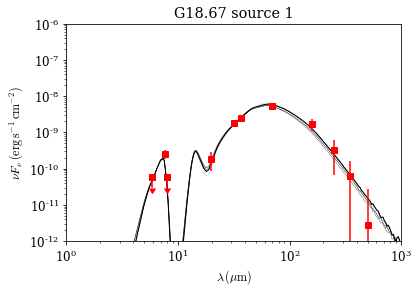

In [ ]:
G18p67_src1_md = ModelPlotter(G18p67_src1_sed_fit)
G18p67_src1_md.plot_multiple_seds(models=G18p67_src1_results_3p[0:5],
                               figsize=(6,4),
                               xlim=[1e0,1e3],ylim=[1e-12,1e-6],
                               title='G18.67 source 1',
                               marker='rs',cmap='gray',colorbar=False,
                               figname=None)

Or all the models satisfying a condition, for example all models with χ2 below 2.

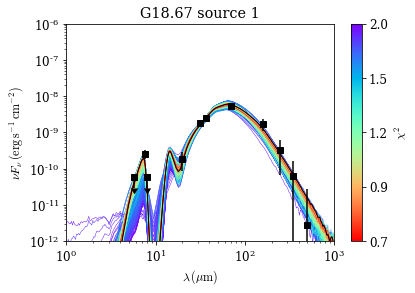

In [ ]:
G18p67_src1_md.plot_multiple_seds(models=G18p67_src1_results_4p[G18p67_src1_results_4p['chisq_nonlim']<2.0],
                               figsize=(6,4),
                               xlim=[1e0,1e3],ylim=[1e-12,1e-6],
                               title='G18.67 source 1',
                               marker='ks',cmap='rainbow_r',colorbar=True,
                               figname=None)

We can also plot the 2D distribution of the three main physical parameters of the model grid, color coded by χ2, to help visualize the extent of degeneracies that are present in the SED fitting:

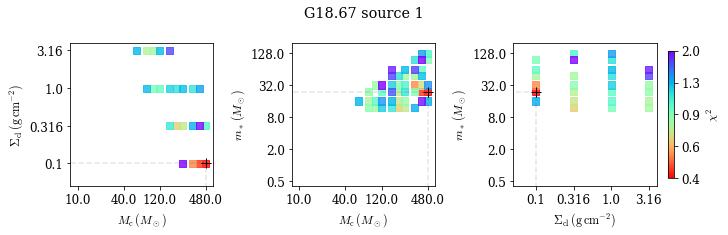

In [23]:
G18p67_src1_md.plot2d(models=G18p67_src1_results_3p[G18p67_src1_results_3p['chisq_nonlim']<=2.0],
                  figsize=(10, 5),
                  marker='s',
                  markersize=50,
                  cmap='rainbow_r',
                  title='G18.67 source 1',
                  figname=None)

Finally, now that we've looked at one example, let's plot the SED results for all of the sources in the region.

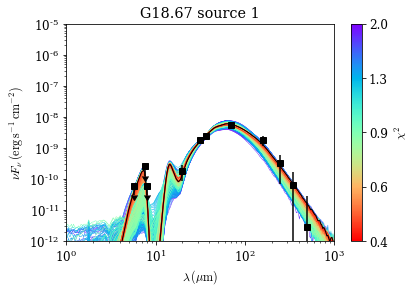

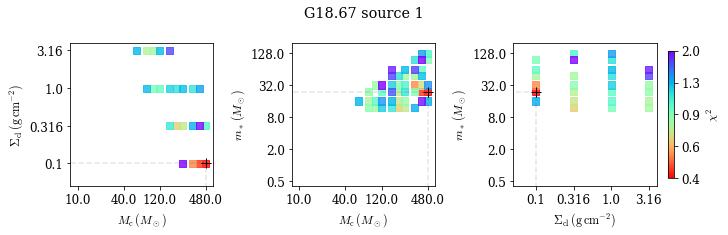

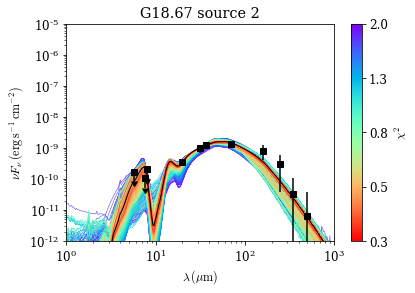

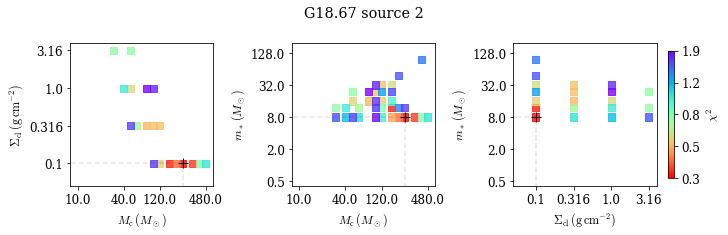

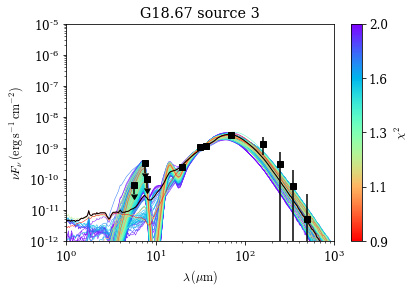

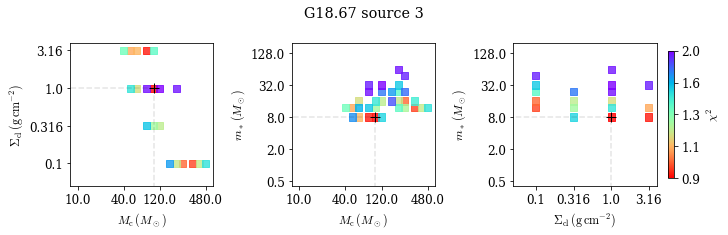

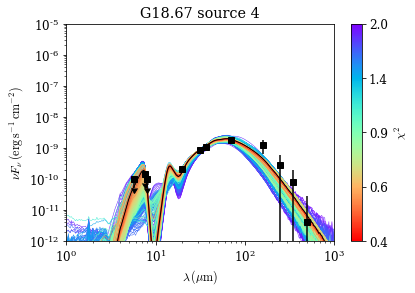

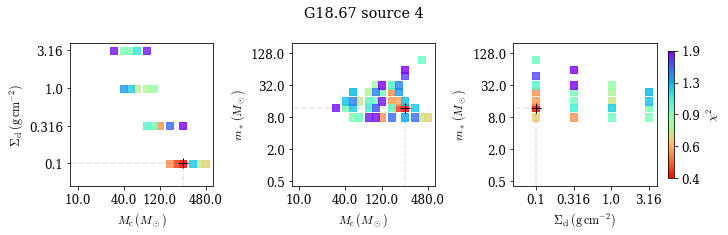

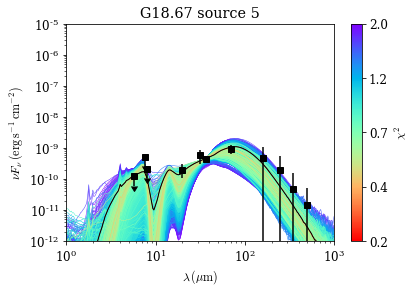

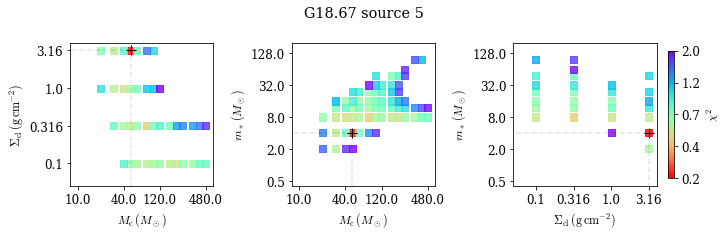

In [24]:
for i in range(len(G18pt67_coords)):

   source_sed_fit = G18p67_sed_fits[i]
   source_name = 'G18.67 source ' + str(i+1)

   source_results_3p = source_sed_fit.get_model_info(keys=['mcore','sigma','mstar'])    
   source_results_4p = source_sed_fit.get_model_info(keys=['mcore','sigma','mstar','theta_view'])
   
   source_model_plotter = ModelPlotter(source_sed_fit)

   source_model_plotter.plot_multiple_seds(models=source_results_4p[source_results_4p['chisq_nonlim']<2.0],
                              figsize=(6,4),
                              title=source_name,
                              marker='ks',cmap='rainbow_r',colorbar=True,
                              figname=None)
   
   source_model_plotter.plot2d(models=source_results_3p[source_results_3p['chisq_nonlim']<=2.0],
                  figsize=(10, 5),
                  marker='s',
                  markersize=50,
                  cmap='rainbow_r',
                  title=source_name,
                  figname=None)

---
---
<font size="2">Authors:

Z. Telkamp (Department of Astronomy, University of Virginia: Charlottesville, VA, USA)

R. Fedriani (Instituto de Astrofísica de Andalucía: Granada, Andalusia, ES)

Z. Tarafder (Department of Astronomy, University of Virginia: Charlottesville, VA, USA)


Last update: 7 April 2026

---